In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [17]:
# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['target'] = iris.target
df['species'] = df['target'].map(
    {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
)

# Display first five rows
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
# Select only Setosa and Non-Setosa
# Setosa = 0, Non-Setosa = 1 or 2

X = df[['sepal length (cm)', 'sepal width (cm)']].values

# Binary target
y = np.where(df['target'] == 0, 0, 1)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nClass distribution:")
print(pd.Series(y).value_counts())


Feature shape: (150, 2)
Target shape: (150,)

Class distribution:
1    100
0     50
Name: count, dtype: int64


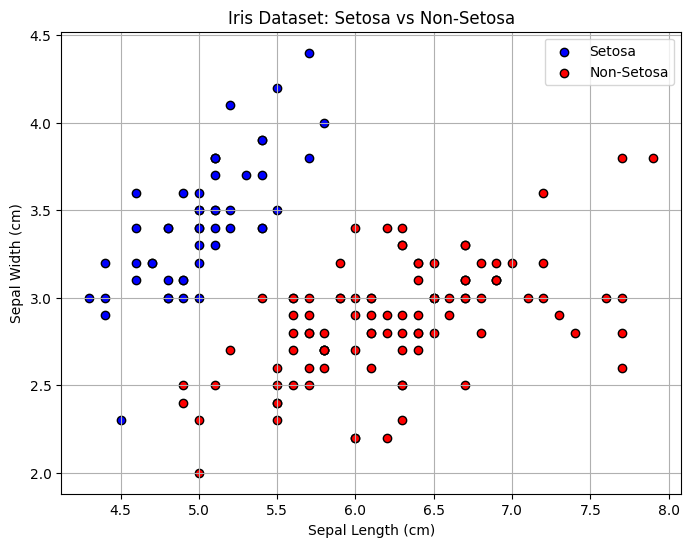

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color='blue',
    label='Setosa',
    edgecolor='black'
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color='red',
    label='Non-Setosa',
    edgecolor='black'
)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Dataset: Setosa vs Non-Setosa')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 120
Testing samples: 30


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 scaled training samples:")
print(X_train_scaled[:5])


First 5 scaled training samples:
[[-1.75307277 -0.33867245]
 [ 1.03889541  0.57460157]
 [ 0.18916596 -1.93690196]
 [-0.53917357  0.80292007]
 [-0.90334333  1.71619408]]


In [7]:
# Create Linear SVM
svm_model = SVC(
    kernel='linear',
    C=1.0
)

# Train the model
svm_model.fit(X_train_scaled, y_train)

print("Linear SVM model trained successfully!")


Linear SVM model trained successfully!


In [8]:
# Predict test data
y_pred = svm_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

print("\nActual values:")
print(y_test)


Predictions:
[1 1 1 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 1 1 1 1]

Actual values:
[1 1 1 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 1 1 1 1]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Setosa', 'Non-Setosa']
))


Accuracy: 1.0

Confusion Matrix:
[[10  0]
 [ 0 20]]

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Non-Setosa       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



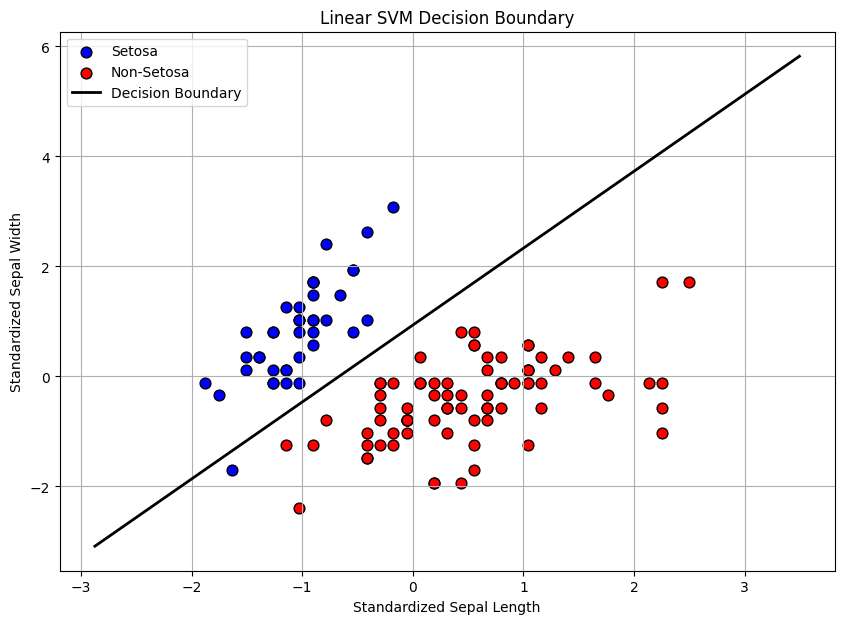

In [10]:
# Plot training data
plt.figure(figsize=(10, 7))

plt.scatter(
    X_train_scaled[y_train == 0, 0],
    X_train_scaled[y_train == 0, 1],
    color='blue',
    label='Setosa',
    edgecolor='black',
    s=60
)

plt.scatter(
    X_train_scaled[y_train == 1, 0],
    X_train_scaled[y_train == 1, 1],
    color='red',
    label='Non-Setosa',
    edgecolor='black',
    s=60
)

# Get model coefficients
w = svm_model.coef_[0]
b = svm_model.intercept_[0]

# Create x-axis values
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

xx = np.linspace(x_min, x_max, 500)

# Decision boundary:
# w0*x + w1*y + b = 0
yy = -(w[0] * xx + b) / w[1]

plt.plot(
    xx,
    yy,
    'k-',
    linewidth=2,
    label='Decision Boundary'
)

plt.xlabel('Standardized Sepal Length')
plt.ylabel('Standardized Sepal Width')
plt.title('Linear SVM Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()


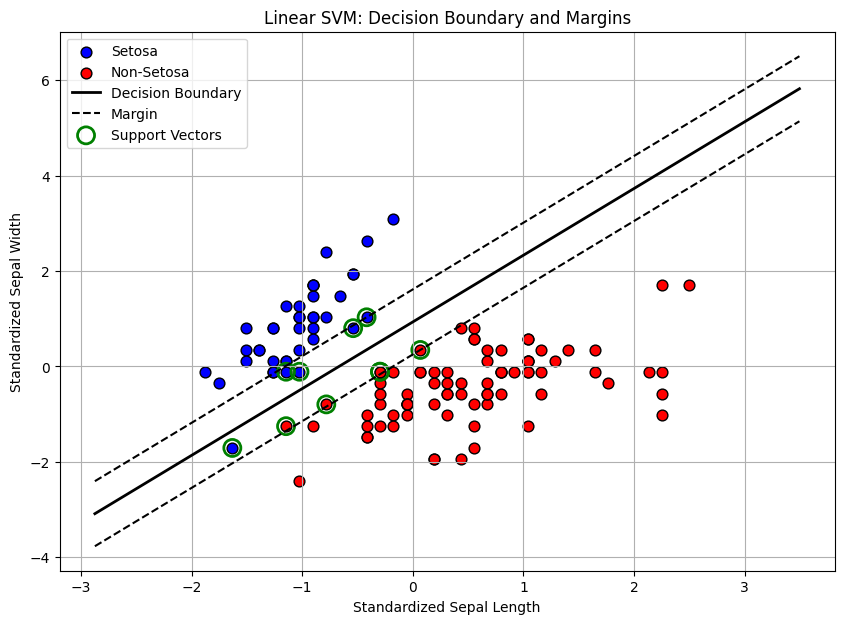

In [11]:
plt.figure(figsize=(10, 7))

# Plot Setosa
plt.scatter(
    X_train_scaled[y_train == 0, 0],
    X_train_scaled[y_train == 0, 1],
    color='blue',
    label='Setosa',
    edgecolor='black',
    s=60
)

# Plot Non-Setosa
plt.scatter(
    X_train_scaled[y_train == 1, 0],
    X_train_scaled[y_train == 1, 1],
    color='red',
    label='Non-Setosa',
    edgecolor='black',
    s=60
)

# x values
xx = np.linspace(
    X_train_scaled[:, 0].min() - 1,
    X_train_scaled[:, 0].max() + 1,
    500
)

# Decision boundary
decision_boundary = -(w[0] * xx + b) / w[1]

# Margin +1
margin_positive = -(w[0] * xx + b - 1) / w[1]

# Margin -1
margin_negative = -(w[0] * xx + b + 1) / w[1]

# Plot decision boundary
plt.plot(
    xx,
    decision_boundary,
    'k-',
    linewidth=2,
    label='Decision Boundary'
)

# Plot margins
plt.plot(
    xx,
    margin_positive,
    'k--',
    linewidth=1.5,
    label='Margin'
)

plt.plot(
    xx,
    margin_negative,
    'k--',
    linewidth=1.5
)

# Highlight support vectors
plt.scatter(
    svm_model.support_vectors_[:, 0],
    svm_model.support_vectors_[:, 1],
    s=150,
    facecolors='none',
    edgecolors='green',
    linewidth=2,
    label='Support Vectors'
)

plt.xlabel('Standardized Sepal Length')
plt.ylabel('Standardized Sepal Width')
plt.title('Linear SVM: Decision Boundary and Margins')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
print("Number of support vectors:", len(svm_model.support_vectors_))

print("\nSupport vectors:")
print(svm_model.support_vectors_)


Number of support vectors: 10

Support vectors:
[[-0.53917357  0.80292007]
 [-1.02473325 -0.11035394]
 [-1.14612317 -0.11035394]
 [-1.63168285 -1.70858346]
 [-0.41778364  1.03123857]
 [-0.29639372 -0.11035394]
 [-0.29639372 -0.11035394]
 [-0.78195341 -0.79530945]
 [ 0.06777604  0.34628306]
 [-1.14612317 -1.25194646]]


In [13]:
# Calculate norm of weight vector
w_norm = np.linalg.norm(w)

# Calculate margin width
margin_width = 2 / w_norm

print("Weight vector:", w)
print("||w|| =", w_norm)
print("Margin width =", margin_width)


Weight vector: [ 2.05101145 -1.46627179]
||w|| = 2.5212300386241577
Margin width = 0.7932635933099565


In [14]:
# Example new Iris flower
new_sample = np.array([[5.0, 3.4]])

# Scale using the same scaler
new_sample_scaled = scaler.transform(new_sample)

# Prediction
prediction = svm_model.predict(new_sample_scaled)

if prediction[0] == 0:
    print("Prediction: Setosa")
else:
    print("Prediction: Non-Setosa")


Prediction: Setosa
